# 17_机器学习模型评估方法-混淆矩阵

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


这一小节，咱们来聊聊混淆矩阵（Confusion Matrix）。

咱们举个简单的例子：

假设你在做一个模型，帮医生判断一个病人有没有得某种病。

这个模型的输出就是 => “患病” 或 “没病”。

模型的结果对不对，总得有个办法去“核对”一下\~

所以我们就需要一个东西，把 **模型的预测结果** 和 **真实的情况** 一一对比 => 这就是混淆矩阵要干的事！

### 混淆矩阵长啥样？来看“表格”就懂了：

对于二分类问题（比如患病 / 没病），混淆矩阵就是一个 2×2 的表：

| 实际 \ 预测 | 预测：患病（Positive） | 预测：没病（Negative） |
|-|-|-|
| 实际患病（Positive） | 真阳性 TP（True Positive） | 假阴性 FN（False Negative） |
| 实际没病（Negative） | 假阳性 FP（False Positive） | 真阴性 TN（True Negative） |

我们来把四个格子拆开讲：

**TP（真阳性）**：模型说“患病”，实际上也真的患病。

👉 比如有 100 个病人真的得了病，你的模型预测出了 80 个，这 80 个就属于 TP。

**TN（真阴性）**：模型说“没病”，实际上也没病。也对了！

👉 模型说这个人健康，结果人家确实也健康，OK，TN。

**FP（假阳性）**：模型说“患病”，但其实人家没病。误报了！  
👉 模型吓了人一跳，明明没病，给人预测成患病。

**FN（假阴性）**：模型说“没病”，但实际上患病。漏诊了！

👉 这是最严重的，人家患病你却说没事，这个不能接受！

### 常见指标

#### 1. **准确率（Accuracy）**

就是模型猜对的总数 / 所有样本总数


$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$


举例：总共100个病人，你预测对了90个，那准确率就是 90%。

#### 2. **精确率（Precision）**

在所有**你说患病的人里**，有多少是真的患病的？


$$
\text{Precision} = \frac{TP}{TP + FP}
$$


你说患病的100个人，结果只有80个真患病，精确率就是80%。

#### 3. **召回率（Recall，也叫灵敏度 Sensitivity）**

在所有**真的患病的人里**，你抓住了多少个？


$$
\text{Recall} = \frac{TP}{TP + FN}
$$


有100个病人真的患病，你找出了80个，召回率就是80%。

#### 4. **F1 分数（F1-Score）**

是精确率和召回率的“调和平均数”（有点像平均值，但更偏向平衡两者）


$$
\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$


当精确率和召回率差不多时，F1分数高；如果两个差得很远，F1分数会低。

## 完整案例

我们选用 scikit-learn 内置的乳腺癌数据集，这是一个经典的二分类数据集，包含 30 个特征（如肿瘤半径、纹理等）和两类标签（`malignant` 恶性/`benign` 良性）。

Classification Report:
               precision    recall  f1-score   support

   malignant       0.92      0.91      0.91        64
      benign       0.94      0.95      0.95       107

    accuracy                           0.94       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171



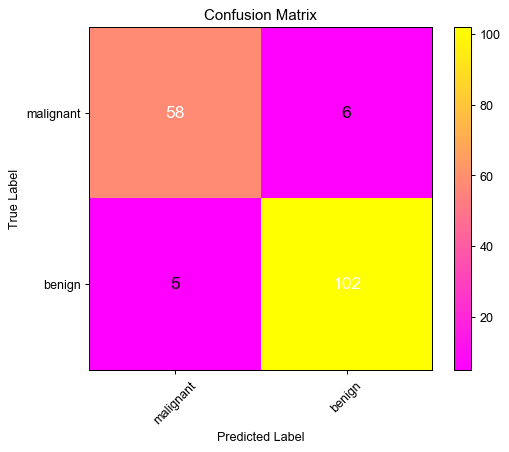

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# 1. 加载数据集
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names
target_names = data.target_names

# 2. 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. 训练模型
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# 4. 预测
y_pred = clf.predict(X_test)

# 5. 计算混淆矩阵
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# 6. 打印分类报告
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=target_names))

# 7. 可视化混淆矩阵
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap='spring') 
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = [0, 1]
plt.xticks(tick_marks, target_names, rotation=45)
plt.yticks(tick_marks, target_names)

# 在矩阵上标注数值
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontsize=14)

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

1. **划分训练集和测试集**`test_size=0.3`：将 30% 的样本留作测试，其余 70% 用于训练。`stratify=y`：确保训练集和测试集中正负样本比例与原始数据相同，避免类别不平衡导致评估失真。
2. **训练随机森林分类器**我们用随机森林（100 棵决策树）来拟合训练数据。随机森林通常对特征尺度不敏感，也能自动评估特征重要性，且在许多应用中表现良好。
3. **在测试集上预测**对 30% 留下的测试样本进行标签预测，得到 `y_pred`。
4. **计算混淆矩阵**`confusion_matrix(y_test, y_pred)` 返回一个 2×2 矩阵，按如下顺序 `[[TN, FP], [FN, TP]]` 排列。
5. **打印分类报告**除了混淆矩阵，我们还输出了精确率、召回率、F1 分数等常见指标，以便对比、验证。
6. **可视化混淆矩阵**使用 `matplotlib.pyplot.imshow` 画出热力图。

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
Classification Report:
               precision    recall  f1-score   support

   malignant       0.92      0.91      0.91        64
      benign       0.94      0.95      0.95       107

    accuracy                           0.94       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171
```

**分类报告** 显示：

- 恶性（malignant）类别的精确率约 0.92，召回率约 0.91。
- 良性（benign）类别的精确率约 0.94，召回率约 0.95。
- 整体准确率约 0.94。

![原文参考图，当前结果见代码输出](attachments/img_001.png)

**混淆矩阵** 中四个值：

- TP（真正例，预测恶性且真实恶性）= 58
- FN（假负例，预测良性但真实恶性）= 6
- FP（假正例，预测恶性但真实良性）= 5
- TN（真负例，预测良性且真实良性）= 102

从数值上看：

- 我们将 64 个真实恶性样本中正确识别出了 58 个（漏诊 6 个）。
- 在 107 个真实良性样本中，误把 5 个预测成恶性（误报），其余 102 个正确识别。

案例中，我们使用随机森林对乳腺癌数据集进行二分类，并结合混淆矩阵做了深入的误报/漏报分析，辅以可视化呈现。混淆矩阵不仅让我们看清了 TP、FP、FN、TN 的分布，还能延伸出一系列评价指标，帮助不同业务场景做出更精准的模型优化与部署决策。

## 模型分析

### 使用混淆矩阵的优缺点

**优点：**

1. **直观全景**：混淆矩阵把模型在各类别上的预测结果可视化成四个格子，能够一眼看出“漏诊”（FN）和“误报”（FP）的数量，远比单纯一个准确率数字更具信息量。
2. **多指标衍生**：基于 TP / FP / FN / TN，可以衍生出精确率、召回率、特异性（Specificity）、F1 分数等多种指标，应对不同场景需求。
3. **类别不平衡时更可靠**：当某类样本极少或极多时，准确率会严重失真，混淆矩阵能揭示出类别不平衡带来的预测偏差。
4. **易于可视化和比较**：对比不同模型或同模型不同参数配置下的混淆矩阵，可以直观地看出性能变化。

**缺点：**

1. **仅限于分类问题**：混淆矩阵只能用于分类，回归问题无法应用。
2. **维度随类别数增长**：多分类问题下混淆矩阵维度为 $K \times K$（K 类），当类别很多时，矩阵变大，分析和可视化都不够直观。
3. **难以一目衡量整体性能**：四个数值本身需要进一步提炼成精确率、召回率等指标，才能快速比较不同模型，单看矩阵不一定能迅速判优劣。
4. **忽略阈值敏感性**：混淆矩阵是基于固定阈值（通常 0.5）得出的，如果用户需要考察不同阈值下的性能变化，需额外绘制 ROC 曲线或 PR 曲线。

### 何时优选使用混淆矩阵

**二分类且关注误报/漏报成本**：如医疗诊断、信用卡欺诈检测、垃圾邮件过滤等场景，对“将有病/欺诈/垃圾邮件错过”或“误报正常样本”有不同成本时，混淆矩阵能帮助量化这些成本。

**数据集类别分布失衡**：当正负样本比例极度不平衡时，准确率高往往是“虚高”，此时混淆矩阵和召回率、精确率等才是评估模型是否可靠的关键。

**模型调参和比较**：在调节分类阈值、调整样本权重、或对比不同分类器（如决策树 vs 随机森林 vs SVM）时，通过混淆矩阵可以直观看出不同模型在各类样本上的表现差异，帮助做出更加合理的模型选择。

**可视化展示报告**：向领域专家（如医生、金融风控人员）汇报模型结果时，混淆矩阵可视化是一种专业且易于理解的方式，能够一目了然地展示模型在关键指标上的表现。

## 最后

混淆矩阵能帮我们一眼看出模型哪些地方分对了、哪些地方老出错。它比单纯的准确率更细，比如能区分“假阳性”和“假阴性”的情况。